# Lyα forest inversion with the fluctuating Gunn–Peterson approximation

This notebook demonstrates the simplest physically motivated inversion of a Lyα forest spectrum. Starting from a CAMELS gas-density skewer, we will

1. define baryonic and cold-dark-matter overdensities;
2. use the neutral-hydrogen density and temperature along the same sightline to generate a continuous-field Voigt forest;
3. pass that forest through Gaussian instrumental smoothing and noise;
4. apply the direct pixelwise FGPA inverse to the mock observed flux; and
5. use the approximation that diffuse baryons trace dark matter to construct a DM-density proxy.

The final comparison uses the CAMELS DM field only as validation truth. It is **not** used to calibrate the reconstruction.

> **Scope.** The mock spectrum uses continuous-field Voigt absorption with thermal and natural broadening. The inverse reconstruction uses the local FGPA relation. A signed peculiar-velocity component is not available in these CMD grids, so the forward model includes Hubble flow but no peculiar-velocity distortion. Gaussian instrumental resolution and flux noise are included explicitly.

## 1. Imports and configuration

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, special
from scipy.optimize import brentq
from astropy import units as u
from astropy.constants import c, k_B, m_e, m_p
from astropy.cosmology import Planck18 as cosmo

data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

seed = 0
y_index = 64
z_index = 64
box_size = 25.0  # comoving Mpc/h
box_redshift = 2.0

# === User-adjustable mock-observation settings ===
signal_to_noise = 5.0         # S/N per native flux pixel
instrument_fwhm_kms = 120.0  # Gaussian instrumental FWHM [km/s]
noise_seed = 2026

# The FGPA thermal relation and photoionization rate are calibrated below

## 2. Extract gas, neutral-hydrogen, dark-matter, and temperature skewers

The density files contain $27$ simulations with shape

$$(N_{\rm simulation},N_x,N_y,N_z)=(27,128,128,128).$$

We select a line of sight along $x$ by fixing $(y,z)=(64,64)$. For any component $i$, define

$$\Delta_i(x)\equiv\frac{\rho_i(x)}{\bar\rho_i}, \qquad \delta_i(x)\equiv\Delta_i(x)-1.$$

$\Delta$ is the overdensity factor used in most Lyα work; $\delta$ is the density contrast. The denominator is the mean of the complete three-dimensional simulation box, not the mean of this particular skewer. Consequently, the mean of one finite skewer need not equal one.

In [ ]:
gas_boxes = np.load(
    data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
HI_boxes = np.load(
    data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
dm_boxes = np.load(
    data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
temperature_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

number_of_cells = gas_boxes.shape[1]
cell_size = box_size / number_of_cells
x = (np.arange(number_of_cells) + 0.5) * cell_size

gas_box_mean = gas_boxes[seed].mean(dtype=np.float64)
dm_box_mean = dm_boxes[seed].mean(dtype=np.float64)

rho_gas = gas_boxes[seed, :, y_index, z_index].astype(np.float64)
rho_dm = dm_boxes[seed, :, y_index, z_index].astype(np.float64)
temperature = temperature_boxes[seed, :, y_index, z_index].astype(np.float64)
rho_HI = HI_boxes[seed, :, y_index, z_index].astype(np.float64)

Delta_b_true = rho_gas / gas_box_mean
Delta_dm_true = rho_dm / dm_box_mean

print(f"Cell width: {cell_size:.3f} comoving Mpc/h")
print(f"3D gas-density mean: {gas_box_mean:.4e} (Msun/h)/(Mpc/h)^3")
print(f"3D CDM-density mean: {dm_box_mean:.4e} (Msun/h)/(Mpc/h)^3")
print(f"Mean Delta_b on this skewer: {Delta_b_true.mean():.3f}")
print(f"Mean Delta_dm on this skewer: {Delta_dm_true.mean():.3f}")

Cell width: 0.195 comoving Mpc/h
3D gas-density mean: 1.3430e+10 (Msun/h)/(Mpc/h)^3
3D CDM-density mean: 6.9665e+10 (Msun/h)/(Mpc/h)^3
Mean Delta_b on this skewer: 0.875
Mean Delta_dm on this skewer: 0.785


Gas and CDM arrays identical: False
Gas–CDM correlation: 0.960; median relative difference: 7.6%


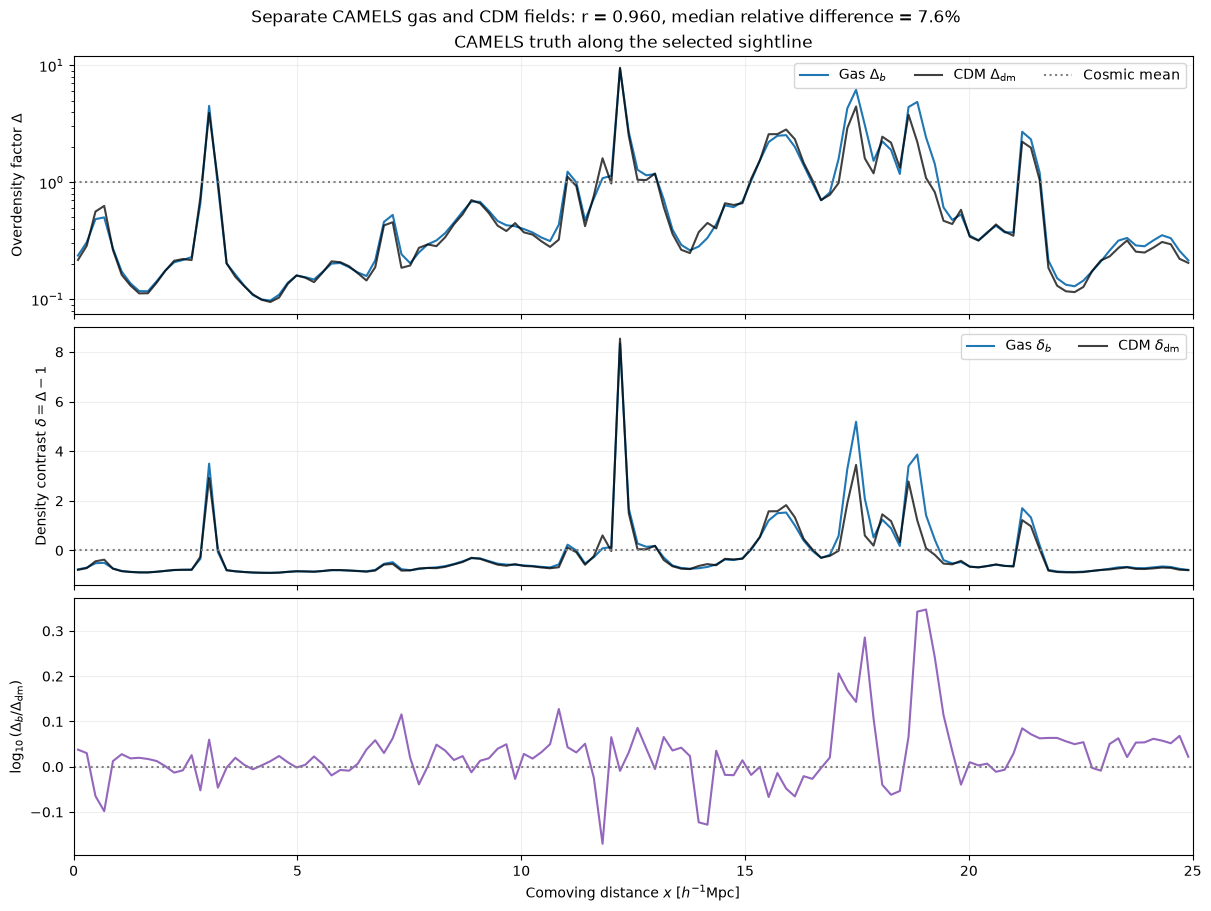

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="tab:blue", label=r"Gas $\Delta_b$")
axes[0].semilogy(x, Delta_dm_true, color="black", alpha=0.75, label=r"CDM $\Delta_{\rm dm}$")
axes[0].axhline(1.0, color="0.5", ls=":", label="Cosmic mean")
axes[0].set_ylabel(r"Overdensity factor $\Delta$")
axes[0].set_title("CAMELS truth along the selected sightline")
axes[0].legend(ncol=3)

axes[1].plot(x, Delta_b_true - 1.0, color="tab:blue", label=r"Gas $\delta_b$")
axes[1].plot(x, Delta_dm_true - 1.0, color="black", alpha=0.75, label=r"CDM $\delta_{\rm dm}$")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel(r"Density contrast $\delta=\Delta-1$")
axes[1].legend(ncol=2)

log_density_ratio = np.log10(Delta_b_true / Delta_dm_true)
axes[2].plot(x, log_density_ratio, color="tab:purple")
axes[2].axhline(0.0, color="0.5", ls=":")
axes[2].set_ylabel(r"$\log_{10}(\Delta_b/\Delta_{\rm dm})$")
axes[2].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

correlation = np.corrcoef(Delta_b_true, Delta_dm_true)[0, 1]
median_relative_difference = np.median(np.abs(Delta_b_true-Delta_dm_true)/Delta_dm_true)
fig.suptitle(f"Separate CAMELS gas and CDM fields: r = {correlation:.3f}, median relative difference = {median_relative_difference:.1%}")
fig.savefig(output_directory / "FGPA_truth_fields.png", dpi=150, bbox_inches="tight")
print(f"Gas and CDM arrays identical: {np.array_equal(Delta_b_true, Delta_dm_true)}")
print(f"Gas–CDM correlation: {correlation:.3f}; median relative difference: {median_relative_difference:.1%}")
plt.show()

Gas and dark matter follow the same large-scale structures, but they are not identical. Gas pressure and feedback redistribute baryons, while the gridded CDM field can retain sharper peaks. This difference will set the accuracy limit of the final DM proxy.

## 3. Inspect the temperature skewer

The temperature cube is sampled at exactly the same $(x,y,z)$ cells as the density skewer. It sets the thermal Doppler width in the Voigt profile. The temperature relation introduced later is part of the inversion model.

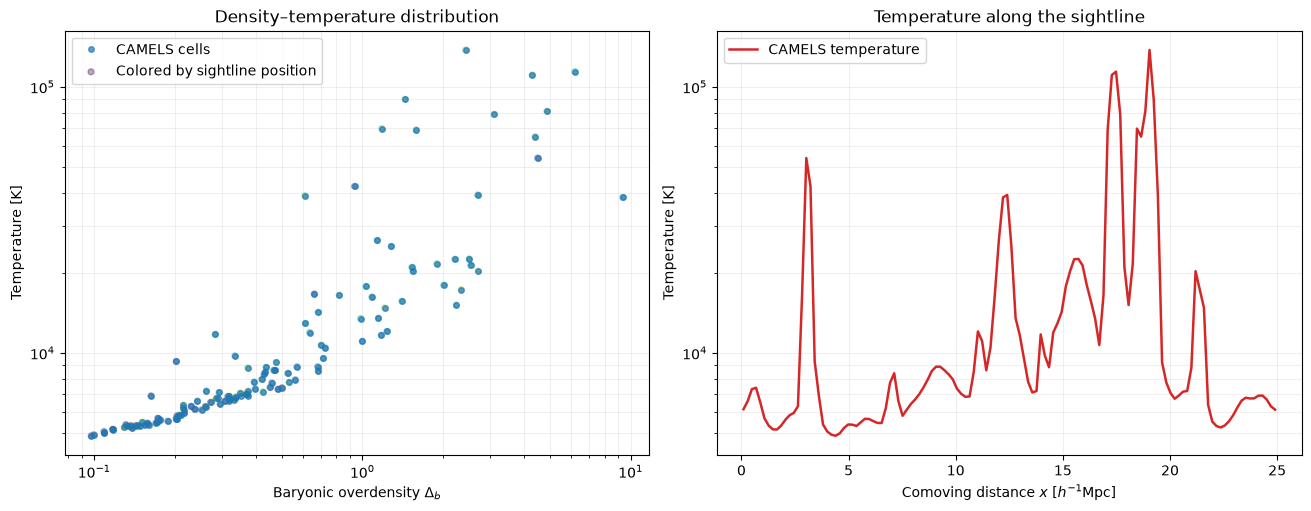

In [ ]:
temperature_reference = 10_000.0  # K; FGPA inversion normalization

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].loglog(
    Delta_b_true,
    temperature,
    "o",
    ms=4,
    color="tab:blue",
    alpha=0.7,
    label="CAMELS cells",
)
axes[0].scatter(
    Delta_b_true,
    temperature,
    s=18,
    c=x,
    cmap="viridis",
    alpha=0.35,
    label="Colored by sightline position",
)
axes[0].set_xlabel(r"Baryonic overdensity $\Delta_b$")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Density–temperature distribution")
axes[0].legend()
axes[0].grid(alpha=0.2, which="both")

axes[1].semilogy(x, temperature, color="tab:red", lw=1.8, label="CAMELS temperature")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[1].set_ylabel("Temperature [K]")
axes[1].set_title("Temperature along the sightline")
axes[1].legend()
axes[1].grid(alpha=0.2, which="both")

fig.savefig(output_directory / "FGPA_temperature_skewer.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Forward model: continuous-field Voigt absorption

The mock spectrum is generated from the neutral-hydrogen density grid and the temperature grid. For each absorber cell $i$ and evaluation pixel $j$, the optical depth is

$$\tau(z_j)=\sum_i\frac{cI_\alpha}{\sqrt{\pi}}\frac{\Delta x_{\rm com}\,n_{{\rm HI},i}}{b_i(1+z_i)}H(a_i,u_{ij}),$$

where

$$b_i=\sqrt{\frac{2k_{\rm B}T_i}{m_{\rm H}}}, \qquad a_i=\frac{\Gamma_\alpha c}{4\pi\nu_\alpha b_i}, \qquad u_{ij}=\frac{c(z_i-z_j)}{b_i(1+z_j)}.$$

Here $H(a,u)=\operatorname{Re}[w(u+ia)]$ is the Voigt function. The neutral-hydrogen grid is converted from its stored comoving mass density to physical number density before evaluating this sum. This includes thermal and natural broadening; the Hubble redshift across the box supplies the velocity coordinate. A signed peculiar-velocity component is not available in the CMD grids, so no peculiar-velocity shift is included. The transmitted flux is $F=\exp(-\tau)$.

The subsequent inverse reconstructs density with the local FGPA relation.

In [ ]:
hydrogen_mass_g = (m_p + m_e).to_value(u.g)
CMD_density_unit = (u.Msun / cosmo.h) / (u.Mpc / cosmo.h) ** 3

H_z = cosmo.H(box_redshift).to_value(u.km / u.s / u.Mpc)
c_kms = c.to_value(u.km / u.s)
distance_from_box_centre_Mpc = (x - box_size / 2.0) / cosmo.h
z_abs = box_redshift + H_z * distance_from_box_centre_Mpc / c_kms

rho_HI_comoving = (rho_HI * CMD_density_unit).to_value(u.g / u.cm**3)
n_HI = rho_HI_comoving * (1.0 + z_abs) ** 3 / hydrogen_mass_g

def continuous_voigt_optical_depth(x_comoving, absorber_redshift, n_HI, temperature):
    """Optical depth from a continuous, cell-sampled HI field."""
    I_alpha = 4.45e-18
    gamma_alpha = 6.262e8
    lambda_alpha_cm = 1215.67e-8
    c_cms = c.to_value(u.cm / u.s)
    nu_alpha = c_cms / lambda_alpha_cm
    x_cm = x_comoving * u.Mpc.to(u.cm) / cosmo.h
    cell_width_cm = np.mean(np.diff(x_cm))
    b_cms = np.sqrt(2.0 * k_B.to_value(u.erg / u.K) * temperature / hydrogen_mass_g)

    a = gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * b_cms)
    u_voigt = (
        c_cms * (absorber_redshift[:, None] - absorber_redshift[None, :])
        / (b_cms[:, None] * (1.0 + absorber_redshift[None, :]))
    )
    voigt = np.real(special.wofz(u_voigt + 1j * a[:, None]))
    prefactor = c_cms * I_alpha * cell_width_cm * n_HI / (
        np.sqrt(np.pi) * b_cms * (1.0 + absorber_redshift)
    )
    return np.sum(prefactor[:, None] * voigt, axis=0)

optical_depth = continuous_voigt_optical_depth(x, z_abs, n_HI, temperature)
flux_intrinsic = np.exp(-optical_depth)

velocity_pixel_width = H_z * (cell_size / cosmo.h) / (1.0 + box_redshift)
instrument_sigma_pixels = (
    instrument_fwhm_kms / (2.0*np.sqrt(2.0*np.log(2.0))) / velocity_pixel_width
)
instrument_matrix = ndimage.gaussian_filter1d(
    np.eye(number_of_cells), instrument_sigma_pixels, axis=0, mode="reflect"
)
flux_convolved = instrument_matrix @ flux_intrinsic
noise_sigma = 1.0/signal_to_noise
noise_rng = np.random.default_rng(noise_seed)
flux_observed = flux_convolved + noise_rng.normal(0.0, noise_sigma, number_of_cells)

print(f"Physical n_HI range = [{n_HI.min():.3e}, {n_HI.max():.3e}] cm^-3")
print(f"Mean transmitted flux = {flux_intrinsic.mean():.5f}")
print(f"Flux range = [{flux_intrinsic.min():.3e}, {flux_intrinsic.max():.5f}]")
print(f"Instrument FWHM = {instrument_fwhm_kms:.1f} km/s ({instrument_sigma_pixels:.2f} sigma pixels)")
print(f"S/N = {signal_to_noise:.1f} per native pixel; sigma_F = {noise_sigma:.4f}")

Physical n_HI range = [4.322e-13, 3.398e-09] cm^-3
Mean transmitted flux = 0.69567
Flux range = [2.682e-14, 0.98904]
Instrument FWHM = 120.0 km/s (2.60 sigma pixels)
S/N = 5.0 per native pixel; sigma_F = 0.2000


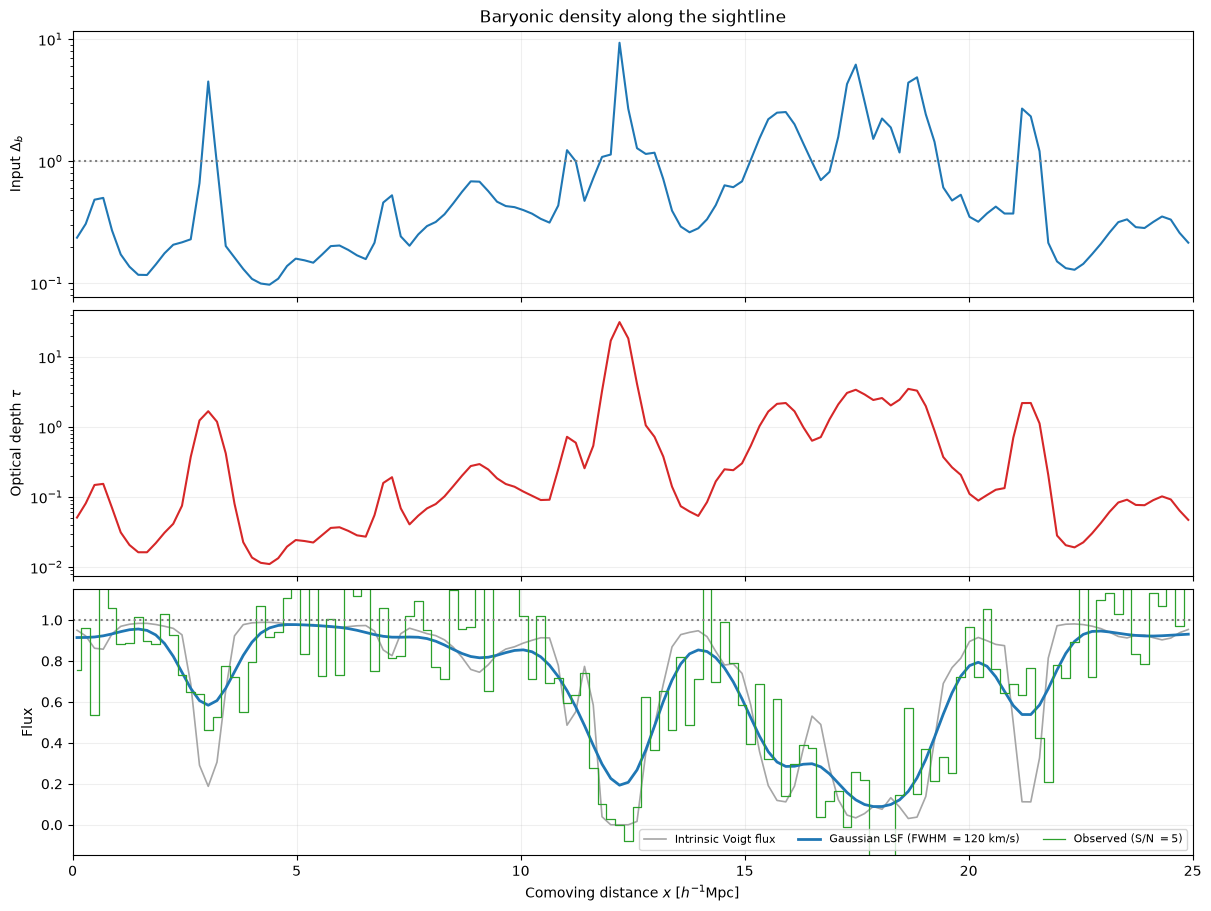

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="tab:blue")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"Input $\Delta_b$")
axes[0].set_title(r"Baryonic density along the sightline")

axes[1].semilogy(x, optical_depth, color="tab:red")
axes[1].set_ylabel(r"Optical depth $\tau$")

axes[2].plot(x, flux_intrinsic, color="0.65", lw=1.2, label="Intrinsic Voigt flux")
axes[2].plot(x, flux_convolved, color="tab:blue", lw=2.0, label=rf"Gaussian LSF (FWHM $={instrument_fwhm_kms:.0f}$ km/s)")
axes[2].step(x, flux_observed, where="mid", color="tab:green", lw=.9, label=rf"Observed (S/N $={signal_to_noise:.0f}$)")
axes[2].axhline(1.0, color="0.5", ls=":")
axes[2].set_ylabel("Flux")
axes[2].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[2].set_ylim(-0.15, 1.15)
axes[2].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "Voigt_forward_model.png", dpi=150, bbox_inches="tight")
plt.show()

The Voigt calculation is non-local: absorption from one cell contributes to nearby spectral pixels through the thermal core and damping wings. High neutral-hydrogen columns produce large optical depth and small transmitted flux. Once $F$ is close to zero, substantially different densities produce nearly indistinguishable absorption; in noisy spectra this is the familiar saturation problem.

## 5. Apply the direct FGPA inverse to the observed flux

The inverse adopts the local FGPA approximation. For the ideal FGPA model, the inverse is algebraic:

$$\tau_{\rm rec}=-\ln F,$$

The inverse does not have access to the temperature or neutral-hydrogen fields used to make the mock spectrum. We first fit the conventional thermal relation $T=T_0\Delta_b^{\gamma-1}$ to the other CAMELS skewers. This gives $\beta=2-0.7(\gamma-1)$ and

$$\boxed{\Delta_{b,\rm rec}=\left[\frac{-\ln F}{A(T_0/10^4\,\mathrm K)^{-0.7}}\right]^{1/\beta}}.$$

For the same calibration skewers, $\Gamma_{\rm HI}$ is chosen so that the FGPA mean transmission matches the mean transmission of their noiseless Voigt mock spectra. Both fitted quantities are then held fixed for the selected sightline. The inverse applies a local formula to the **smoothed, noisy** observed flux even though instrumental convolution and Voigt broadening couple neighbouring pixels. The logarithm requires positive flux, so values are clipped to the noise floor $1/\mathrm{SNR}$; flux above the continuum is clipped just below one.

In [ ]:
calibration_simulations = [sim for sim in range(gas_boxes.shape[0]) if sim != seed]

# Fit ln T = ln T0 + (gamma - 1) ln Delta_b on diffuse calibration cells.
calibration_overdensity = []
calibration_temperature = []
for sim in calibration_simulations:
    Delta_b_sim = (
        gas_boxes[sim, :, y_index, z_index].astype(np.float64)
        / gas_boxes[sim].mean(dtype=np.float64)
    )
    temperature_sim = temperature_boxes[sim, :, y_index, z_index].astype(np.float64)
    diffuse = (Delta_b_sim >= 0.1) & (Delta_b_sim <= 10.0) & (temperature_sim < 1.0e5)
    calibration_overdensity.append(Delta_b_sim[diffuse])
    calibration_temperature.append(temperature_sim[diffuse])

calibration_overdensity = np.concatenate(calibration_overdensity)
calibration_temperature = np.concatenate(calibration_temperature)
temperature_slope, log_T0 = np.polyfit(
    np.log(calibration_overdensity), np.log(calibration_temperature), 1
)
inversion_T0_K = np.exp(log_T0)
inversion_gamma = 1.0 + temperature_slope
inversion_beta = 2.0 - 0.7 * (inversion_gamma - 1.0)
inversion_temperature_normalization = (inversion_T0_K / temperature_reference) ** (-0.7)

# Construct noiseless Voigt mock skewers for the calibration simulations.
calibration_fgpa_shape = []
calibration_mock_flux = []
for sim in calibration_simulations:
    Delta_b_sim = (
        gas_boxes[sim, :, y_index, z_index].astype(np.float64)
        / gas_boxes[sim].mean(dtype=np.float64)
    )
    rho_HI_sim = HI_boxes[sim, :, y_index, z_index].astype(np.float64)
    temperature_sim = temperature_boxes[sim, :, y_index, z_index].astype(np.float64)
    n_HI_sim = (rho_HI_sim * CMD_density_unit).to_value(u.g / u.cm**3)
    n_HI_sim *= (1.0 + z_abs) ** 3 / hydrogen_mass_g
    calibration_mock_flux.append(
        np.exp(-continuous_voigt_optical_depth(x, z_abs, n_HI_sim, temperature_sim))
    )
    calibration_fgpa_shape.append(
        Delta_b_sim ** inversion_beta * inversion_temperature_normalization
    )

calibration_fgpa_shape = np.concatenate(calibration_fgpa_shape)
mean_flux_mock = np.mean(calibration_mock_flux)

# Photoionization equilibrium sets the FGPA normalization A(Gamma_HI).
hydrogen_mass_fraction = 0.76
electron_to_hydrogen = 1.0 + (1.0 - hydrogen_mass_fraction) / (2.0 * hydrogen_mass_fraction)
mean_baryon_density = (
    cosmo.Ob0 * cosmo.critical_density0 * (1.0 + box_redshift) ** 3
).to_value(u.g / u.cm**3)
mean_n_H = hydrogen_mass_fraction * mean_baryon_density / hydrogen_mass_g
alpha_HII_reference = 4.2e-13  # cm^3 s^-1 at 10^4 K
H_z_s = cosmo.H(box_redshift).to_value(1 / u.s)
I_alpha = 4.45e-18
c_cms = c.to_value(u.cm / u.s)

def fgpa_amplitude(Gamma_HI):
    mean_n_HI = alpha_HII_reference * electron_to_hydrogen * mean_n_H**2 / Gamma_HI
    return c_cms * I_alpha * mean_n_HI / H_z_s

def mean_flux_residual(log_Gamma_HI):
    Gamma_HI = np.exp(log_Gamma_HI)
    return np.mean(np.exp(-fgpa_amplitude(Gamma_HI) * calibration_fgpa_shape)) - mean_flux_mock

Gamma_HI = np.exp(brentq(mean_flux_residual, np.log(1.0e-15), np.log(1.0e-10)))
A_fgpa = fgpa_amplitude(Gamma_HI)
mean_flux_fgpa_calibration = np.mean(
    np.exp(-A_fgpa * calibration_fgpa_shape)
)

flux_for_log = np.clip(flux_observed, noise_sigma, 1.0 - 1.0e-8)
optical_depth_recovered = -np.log(flux_for_log)
Delta_b_recovered = (
    optical_depth_recovered / (A_fgpa * inversion_temperature_normalization)
) ** (1.0 / inversion_beta)

fractional_baryon_error = (Delta_b_recovered - Delta_b_true) / Delta_b_true

print(f"Temperature fit: T0 = {inversion_T0_K:.0f} K, gamma = {inversion_gamma:.3f}")
print(f"Mean flux: Voigt mocks = {mean_flux_mock:.5f}; FGPA = {mean_flux_fgpa_calibration:.5f}")
print(f"Gamma_HI = {Gamma_HI:.3e} s^-1; FGPA amplitude A = {A_fgpa:.5f}")
print(f"Pixels below the noise floor: {np.count_nonzero(flux_observed < noise_sigma)}")
print(f"Pixels at or above the continuum: {np.count_nonzero(flux_observed >= 1.0)}")
print(f"FGPA exponent beta = {inversion_beta:.3f}")
print(f"Baryon RMSE: {np.sqrt(np.mean((Delta_b_recovered - Delta_b_true)**2)):.3f}")
print(f"Baryon MAE: {np.mean(np.abs(Delta_b_recovered - Delta_b_true)):.3f}")

Temperature fit: T0 = 13841 K, gamma = 1.548
Mean flux: Voigt mocks = 0.67333; FGPA = 0.67333
Gamma_HI = 2.109e-13 s^-1; FGPA amplitude A = 1.24044
Pixels below the noise floor: 15
Pixels at or above the continuum: 33
FGPA exponent beta = 1.616
Baryon RMSE: 1.157
Baryon MAE: 0.558


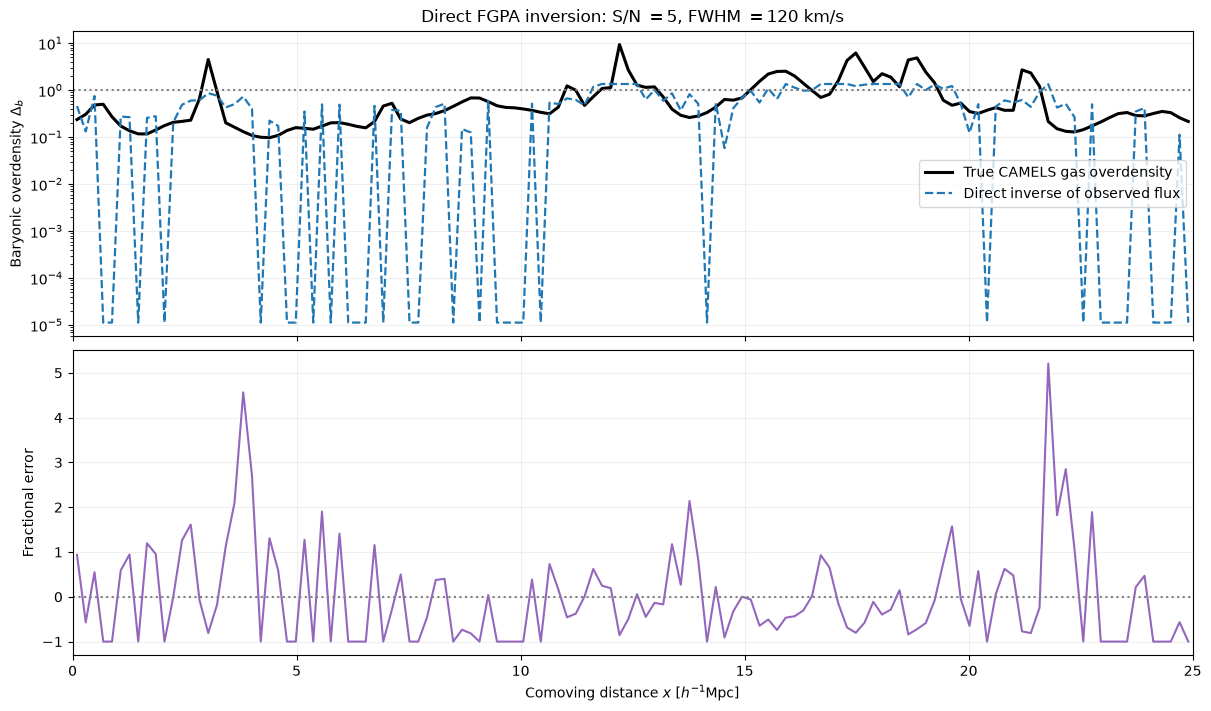

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="black", lw=2.2, label="True CAMELS gas overdensity")
axes[0].semilogy(x, Delta_b_recovered, "--", color="tab:blue", lw=1.6, label="Direct inverse of observed flux")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"Baryonic overdensity $\Delta_b$")
axes[0].set_title(rf"Direct FGPA inversion: S/N $={signal_to_noise:.0f}$, FWHM $={instrument_fwhm_kms:.0f}$ km/s")
axes[0].legend()

axes[1].plot(x, fractional_baryon_error, color="tab:purple")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel("Fractional error")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "FGPA_baryon_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

The direct reconstruction is no longer exact: Gaussian smoothing mixes neighbouring flux pixels, noise is amplified by $-\ln F$, continuum-crossing pixels are clipped, and saturated pixels are limited by the noise floor. This motivates the forward-modelled MAP and simulation-trained neural inversions. The next DM step adds the further approximation that baryons trace CDM.

## 6. From baryonic overdensity to a dark-matter proxy

Lyα absorption is produced by neutral hydrogen, not dark matter. To obtain a DM estimate, we now make the additional approximation

$$\delta_{\rm dm}\simeq\delta_b,$$

or, because both fields are normalized by their own cosmic means,

$$\boxed{\Delta_{\rm dm,pred}\simeq\Delta_{b,\rm rec}}.$$

This is reasonable for diffuse matter on scales where pressure and feedback do not strongly separate gas from dark matter. It is not exact on small or highly nonlinear scales. Importantly, the CAMELS DM truth is not used in this prediction.

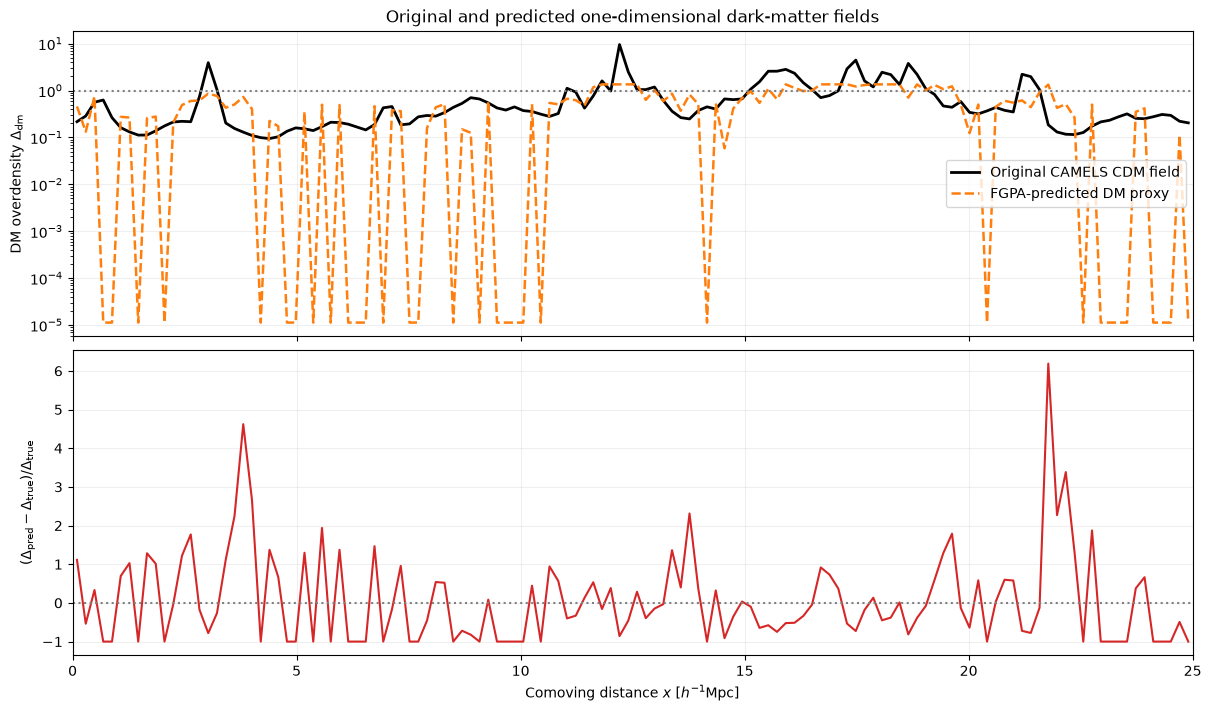

In [ ]:
Delta_dm_predicted = Delta_b_recovered.copy()
dm_fractional_residual = (Delta_dm_predicted - Delta_dm_true) / Delta_dm_true

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_dm_true, color="black", lw=2.0, label="Original CAMELS CDM field")
axes[0].semilogy(x, Delta_dm_predicted, "--", color="tab:orange", lw=1.8, label="FGPA-predicted DM proxy")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"DM overdensity $\Delta_{\rm dm}$")
axes[0].set_title("Original and predicted one-dimensional dark-matter fields")
axes[0].legend()

axes[1].plot(x, dm_fractional_residual, color="tab:red")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel(r"$(\Delta_{\rm pred}-\Delta_{\rm true})/\Delta_{\rm true}$")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "FGPA_dm_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compare field-level and summary statistics

An overplotted field is useful, but it does not fully describe agreement. We therefore compare four complementary summaries:

- a cell-by-cell parity plot;
- the one-point probability distribution of $\log_{10}\Delta$;
- the one-dimensional power spectrum of $\delta=\Delta-1$; and
- the mean, median, standard deviation, and 90th percentile.

These statistics come from only one 128-cell sightline and are illustrative, not precision estimates.

In [ ]:
pearson_r = np.corrcoef(Delta_dm_true, Delta_dm_predicted)[0, 1]
rmse = np.sqrt(np.mean((Delta_dm_predicted - Delta_dm_true) ** 2))
mae = np.mean(np.abs(Delta_dm_predicted - Delta_dm_true))
mean_bias = np.mean(Delta_dm_predicted - Delta_dm_true)

def one_dimensional_power(Delta, spacing):
    """Return P_1D(k)=|dx FFT(delta)|^2/L, omitting the zero mode."""
    density_contrast = Delta - 1.0
    fourier_amplitude = spacing * np.fft.rfft(density_contrast)
    k = 2.0 * np.pi * np.fft.rfftfreq(Delta.size, d=spacing)
    power = np.abs(fourier_amplitude) ** 2 / (Delta.size * spacing)
    return k[1:], power[1:]

def logarithmic_power_bins(k, power, k_min=0.5, k_max=5.0, n_bins=5):
    """Average a 1D power spectrum in fixed logarithmic k bins."""
    edges = np.logspace(np.log10(k_min), np.log10(k_max), n_bins + 1)
    centres = np.sqrt(edges[:-1] * edges[1:])
    in_range = (k >= k_min) & (k <= k_max)
    indices = np.clip(np.digitize(k[in_range], edges) - 1, 0, n_bins - 1)
    binned_power = np.full(n_bins, np.nan)
    for bin_index in range(n_bins):
        values = power[in_range][indices == bin_index]
        if values.size:
            binned_power[bin_index] = values.mean()
    return centres, binned_power

k_true, power_true = one_dimensional_power(Delta_dm_true, cell_size)
k_pred, power_pred = one_dimensional_power(Delta_dm_predicted, cell_size)
k_power, power_true = logarithmic_power_bins(k_true, power_true)
_, power_pred = logarithmic_power_bins(k_pred, power_pred)

statistic_names = ["Mean", "Median", "Std. dev.", "90th pct."]
statistics_true = [
    np.mean(Delta_dm_true),
    np.median(Delta_dm_true),
    np.std(Delta_dm_true),
    np.percentile(Delta_dm_true, 90),
]
statistics_predicted = [
    np.mean(Delta_dm_predicted),
    np.median(Delta_dm_predicted),
    np.std(Delta_dm_predicted),
    np.percentile(Delta_dm_predicted, 90),
]

print(f"Pearson correlation r = {pearson_r:.4f}")
print(f"RMSE in Delta_dm = {rmse:.4f}")
print(f"MAE in Delta_dm = {mae:.4f}")
print(f"Mean bias (predicted - true) = {mean_bias:.4f}")

Pearson correlation r = 0.5387
RMSE in Delta_dm = 1.0077
MAE in Delta_dm = 0.4955
Mean bias (predicted - true) = -0.2613


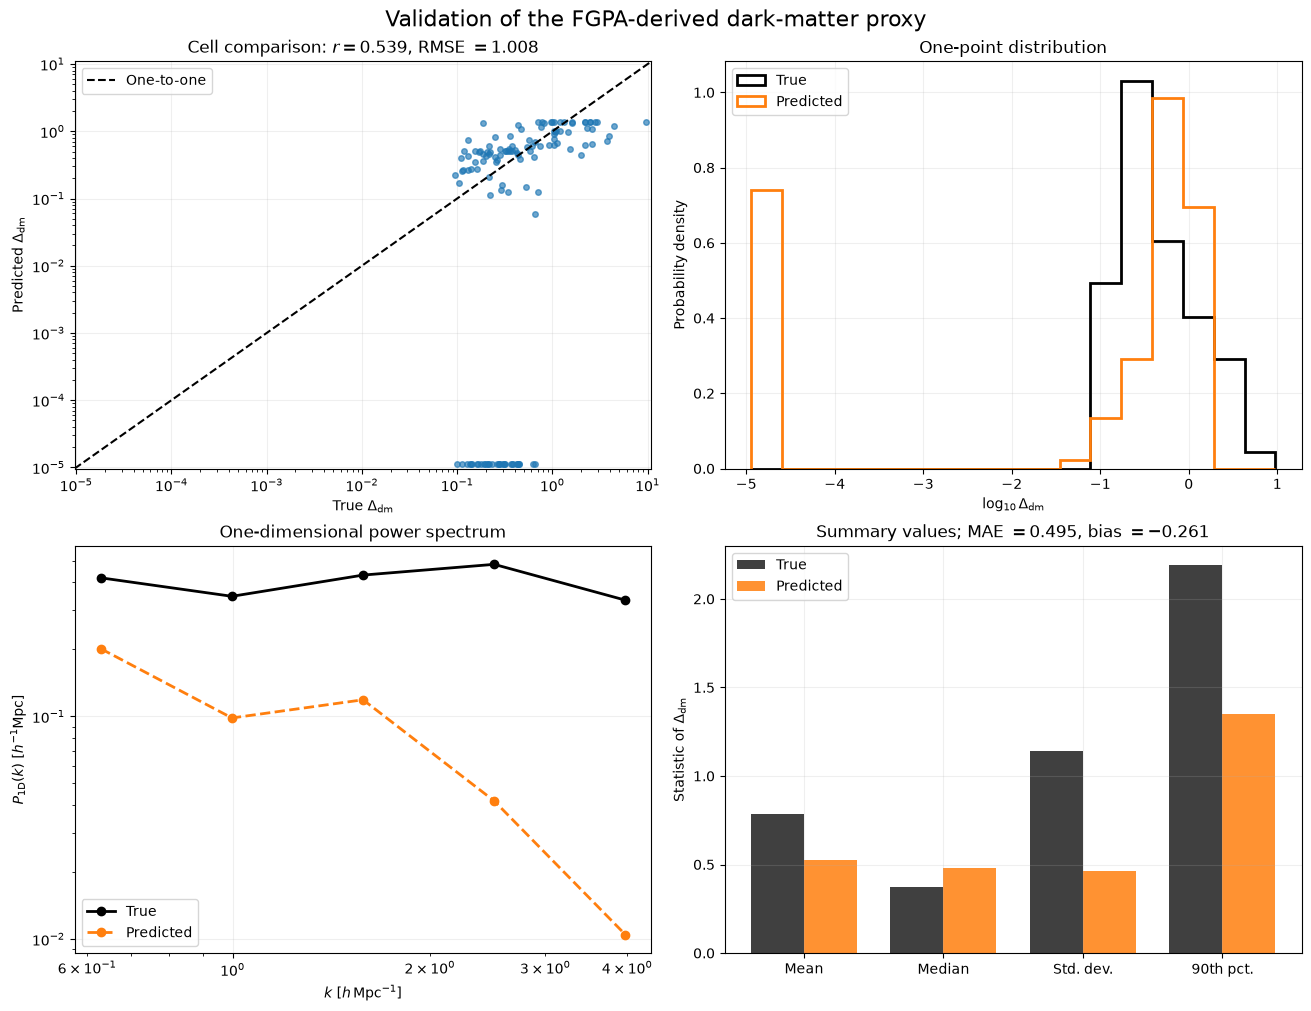

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

limits = [
    min(Delta_dm_true.min(), Delta_dm_predicted.min()) * 0.85,
    max(Delta_dm_true.max(), Delta_dm_predicted.max()) * 1.15,
]
axes[0, 0].loglog(Delta_dm_true, Delta_dm_predicted, "o", ms=4, alpha=0.65, color="tab:blue")
axes[0, 0].plot(limits, limits, "--", color="black", label="One-to-one")
axes[0, 0].set_xlim(limits)
axes[0, 0].set_ylim(limits)
axes[0, 0].set_xlabel(r"True $\Delta_{\rm dm}$")
axes[0, 0].set_ylabel(r"Predicted $\Delta_{\rm dm}$")
axes[0, 0].set_title(rf"Cell comparison: $r={pearson_r:.3f}$, RMSE $={rmse:.3f}$")
axes[0, 0].legend()

log_limits = [
    min(np.log10(Delta_dm_true).min(), np.log10(Delta_dm_predicted).min()),
    max(np.log10(Delta_dm_true).max(), np.log10(Delta_dm_predicted).max()),
]
bins = np.linspace(*log_limits, 18)
axes[0, 1].hist(np.log10(Delta_dm_true), bins=bins, density=True, histtype="step", lw=2.0, color="black", label="True")
axes[0, 1].hist(np.log10(Delta_dm_predicted), bins=bins, density=True, histtype="step", lw=2.0, color="tab:orange", label="Predicted")
axes[0, 1].set_xlabel(r"$\log_{10}\Delta_{\rm dm}$")
axes[0, 1].set_ylabel("Probability density")
axes[0, 1].set_title("One-point distribution")
axes[0, 1].legend()

axes[1, 0].loglog(k_power, power_true, color="black", lw=2.0, marker="o", label="True")
axes[1, 0].loglog(k_power, power_pred, "--", color="tab:orange", lw=2.0, marker="o", label="Predicted")
axes[1, 0].set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axes[1, 0].set_ylabel(r"$P_{1\rm D}(k)\ [h^{-1}{\rm Mpc}]$")
axes[1, 0].set_title("One-dimensional power spectrum")
axes[1, 0].legend()

bar_positions = np.arange(len(statistic_names))
bar_width = 0.38
axes[1, 1].bar(bar_positions - bar_width / 2, statistics_true, bar_width, color="black", alpha=0.75, label="True")
axes[1, 1].bar(bar_positions + bar_width / 2, statistics_predicted, bar_width, color="tab:orange", alpha=0.85, label="Predicted")
axes[1, 1].set_xticks(bar_positions, statistic_names)
axes[1, 1].set_ylabel(r"Statistic of $\Delta_{\rm dm}$")
axes[1, 1].set_title(rf"Summary values; MAE $={mae:.3f}$, bias $={mean_bias:+.3f}$")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.2)

fig.suptitle("Validation of the FGPA-derived dark-matter proxy", fontsize=16)
fig.savefig(output_directory / "FGPA_summary_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. What this experiment establishes—and what it does not

- **Forward model and inversion:** the mock spectrum uses the neutral-hydrogen and temperature grids in the continuous Voigt calculation. The inverse uses only flux plus an assumed $T_0$–$\gamma$ relation.
- **Temperature:** the inversion does not receive the temperature skewer. The editable $T_0$ and $\gamma$ parameters represent external thermal assumptions that would be required for observational data.
- **Dark matter:** the DM result follows only after assuming $\Delta_{\rm dm}\simeq\Delta_b$. Differences from CAMELS truth measure the failure of this tracing approximation on the resolved skewer.
- **Normalization:** the FGPA amplitude $A$ is degenerate with the hydrogen photoionization rate, cosmology, and mean baryon density. Matching an illustrative mean flux supplies its normalization for the inverse.
- **Real spectra:** this notebook includes thermal and natural broadening, finite instrumental resolution, and Gaussian noise. Peculiar velocities and continuum uncertainty remain absent.
- **Regime of validity:** FGPA works best in the diffuse, photoionized IGM. Shocks, self-shielding, galactic environments, and feedback cause departures, especially at high density. A direct comparison of FGPA with hydrodynamical simulations at $z=2$ is given by [Kooistra, Lee & Horowitz (2022)](https://arxiv.org/abs/2201.10169).

### Suggested exercises

1. Vary the inversion assumptions `inversion_T0_K` and `inversion_gamma` and examine the resulting density bias. Separately vary $A$ to represent an incorrect photoionization-rate normalization.
2. Apply a flux floor such as $F_{\rm min}=0.02$ and show that saturated regions become lower limits.
3. Change `signal_to_noise` and `instrument_fwhm_kms` in the first code cell and quantify how the local algebraic inverse degrades.
4. Repeat the analysis for several CAMELS skewers and compare the distribution of correlation coefficients and power-spectrum ratios.